# UC3 Layer 4 — XGBoost (Supervised Residual Classifier)

**Goal:** Train a supervised XGBoost classifier to catch attacks that escape
the unsupervised cascade (L1 Regex → L2 OC-SVM). Unlike L2, this layer
uses **labeled attack data** — it learns the residual decision boundary
that anomaly detection cannot capture with structural features alone.

**Dataset:** CSIC 2010

**Data split strategy:**
- `anomalousTrafficTest` is split 50/50 into **attack-train** and **attack-test**
- `normalTrafficTraining` provides benign training data (same as L2)
- `normalTrafficTest` provides benign test data
- This ensures no attack sample appears in both XGBoost training and final evaluation

**Feature vector (12-dim, shared with L2):** Same `extract_features()` + `ParamVocab`

**Key design decisions:**
- **Independent scaler** — fit on this notebook's training set only
- **`scale_pos_weight`** — compensates for benign/attack class imbalance
- **Probability-based threshold tuning** — `predict_proba` threshold set on
  held-out benign validation data to achieve target FPR
- **Same artifact pattern** as L2 for microservice integration

**Pipeline:**
1. Load parsed CSVs, split attack test data 50/50
2. Feature extraction (same function as L2)
3. Train/val split on training data
4. Scale features (independent `StandardScaler`)
5. Train XGBoost binary classifier
6. Threshold tuning on validation set (FPR-targeted)
7. Evaluation: confusion matrix, classification report, PR-AUC, ROC-AUC
8. Feature importance analysis
9. False negative / false positive analysis
10. Persist scaler + model + threshold + vocab via `joblib`

In [1]:
import os
import numpy as np
import pandas as pd
import math
import joblib
from urllib.parse import unquote, urlparse, parse_qs
import json

from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split
from sklearn.metrics import (
    classification_report, confusion_matrix,
    precision_score, recall_score, f1_score,
    precision_recall_curve, average_precision_score,
    roc_auc_score, roc_curve,
    ConfusionMatrixDisplay,
)
from xgboost import XGBClassifier
import matplotlib.pyplot as plt
import warnings
warnings.filterwarnings("ignore", category=FutureWarning)

# ── Configuration ──────────────────────────────────────────────────────
CSV_DIR   = "./data"
MODEL_DIR = "./models"
os.makedirs(MODEL_DIR, exist_ok=True)

STRUCTURAL_FEATURE_COLS = [
    "request_length", "special_char_count", "special_char_ratio",
    "url_entropy", "body_entropy", "param_count",
    "max_param_value_length", "url_path_depth", "has_body",
]
VOCAB_FEATURE_COLS = [
    "unknown_param_name_count",
    "unknown_param_name_ratio",
    "max_param_name_min_edit_dist",
]
FEATURE_COLS = STRUCTURAL_FEATURE_COLS + VOCAB_FEATURE_COLS

RANDOM_STATE = 42

# ── XGBoost hyperparameters ───────────────────────────────────────────
VAL_SIZE        = 0.2       # fraction of training data held out for threshold tuning
ATTACK_SPLIT    = 0.5       # fraction of anomalousTrafficTest used for training
N_ESTIMATORS    = 200
MAX_DEPTH       = 6
LEARNING_RATE   = 0.1
TARGET_FPR      = 0.01      # target false positive rate for threshold tuning

print("Ready.")

Ready.


## 1. Load & Split Data

In [2]:
df_train_benign = pd.read_csv(os.path.join(CSV_DIR, "normalTrafficTraining.csv"))
df_test_benign  = pd.read_csv(os.path.join(CSV_DIR, "normalTrafficTest.csv"))
df_attack_all   = pd.read_csv(os.path.join(CSV_DIR, "anomalousTrafficTest.csv"))

# Split attack data 50/50: first half for XGBoost training, second half for testing.
# Use integer index split (preserves original ordering — no shuffling).
split_idx = int(len(df_attack_all) * ATTACK_SPLIT)
df_attack_train = df_attack_all.iloc[:split_idx].copy().reset_index(drop=True)
df_attack_test  = df_attack_all.iloc[split_idx:].copy().reset_index(drop=True)

# Assemble training set (benign + attack) and test set
df_xgb_train = pd.concat([df_train_benign, df_attack_train], ignore_index=True)
df_xgb_train["label"] = [0] * len(df_train_benign) + [1] * len(df_attack_train)

df_xgb_test = pd.concat([df_test_benign, df_attack_test], ignore_index=True)
df_xgb_test["label"] = [0] * len(df_test_benign) + [1] * len(df_attack_test)

print(f"Training set:")
print(f"  Benign: {len(df_train_benign):>6,}")
print(f"  Attack: {len(df_attack_train):>6,}  (first {ATTACK_SPLIT:.0%} of anomalousTrafficTest)")
print(f"  Total:  {len(df_xgb_train):>6,}")
print(f"\nTest set:")
print(f"  Benign: {len(df_test_benign):>6,}")
print(f"  Attack: {len(df_attack_test):>6,}  (second {1-ATTACK_SPLIT:.0%} of anomalousTrafficTest)")
print(f"  Total:  {len(df_xgb_test):>6,}")
print(f"\nClass ratio (train): {len(df_train_benign)/len(df_attack_train):.2f} benign per attack")

Training set:
  Benign: 36,000
  Attack: 12,532  (first 50% of anomalousTrafficTest)
  Total:  48,532

Test set:
  Benign: 36,000
  Attack: 12,533  (second 50% of anomalousTrafficTest)
  Total:  48,533

Class ratio (train): 2.87 benign per attack


## 2. Feature Extraction

**CRITICAL:** Same function as L2/L3 — guarantees training-inference feature parity.
URL-decode **before** computing features.

In [3]:
SPECIAL_CHARS = set("'\";<>(){}[]|$`!@#%^*~")

def _shannon_entropy(s: str) -> float:
    if not s:
        return 0.0
    length = len(s)
    freq = {}
    for ch in s:
        freq[ch] = freq.get(ch, 0) + 1
    return -sum((c / length) * math.log2(c / length) for c in freq.values())


def _count_special_chars(s: str) -> int:
    return sum(1 for ch in s if ch in SPECIAL_CHARS)


def _count_params(url: str, body: str, content_type: str) -> int:
    n = 0
    # URL query params
    try:
        parsed = urlparse(url)
        n += len(parse_qs(parsed.query, keep_blank_values=True))
    except Exception:
        pass
    # POST body params (only for form-urlencoded)
    if isinstance(body, str) and isinstance(content_type, str):
        if "application/x-www-form-urlencoded" in content_type.lower():
            try:
                n += len(parse_qs(body, keep_blank_values=True))
            except Exception:
                pass
    return n

def _max_param_value_length(url: str, body: str, content_type: str) -> int:
    vals = []

    try:
        parsed = urlparse(url)
        for v_list in parse_qs(parsed.query, keep_blank_values=True).values():
            vals.extend(v_list)
    except Exception:
        pass

    if isinstance(body, str) and isinstance(content_type, str):
        if "application/x-www-form-urlencoded" in content_type.lower():
            try:
                for v_list in parse_qs(body, keep_blank_values=True).values():
                    vals.extend(v_list)
            except Exception:
                pass

    return max((len(v) for v in vals), default=0)


def _url_path_depth(url: str) -> int:
    try:
        path = urlparse(url).path
        segments = [s for s in path.split("/") if s]
        return len(segments)
    except Exception:
        return 0


def extract_features(df: pd.DataFrame) -> pd.DataFrame:
    # URL-decode first
    decoded_url  = df["url"].fillna("").apply(lambda u: unquote(u))
    decoded_body = df["body"].fillna("")

    # Reconstruct full request string for request_length
    full_request = (
        df["method"].fillna("") + " "
        + decoded_url + " "
        + df["protocol"].fillna("") + "\n"
        + df["headers_raw"].fillna("") + "\n\n"
        + decoded_body
    )

    combined = decoded_url + decoded_body
    spec_count = combined.apply(_count_special_chars)
    combined_len = combined.str.len().replace(0, 1)  # avoid div-by-zero

    features = pd.DataFrame({
        "request_length":       full_request.str.len(),
        "special_char_count":   spec_count,
        "special_char_ratio":   spec_count / combined_len,
        "url_entropy":          decoded_url.apply(_shannon_entropy),
        "body_entropy":         decoded_body.apply(_shannon_entropy),
        "param_count":          [
            _count_params(u, b, ct)
            for u, b, ct in zip(
                decoded_url, decoded_body, df["content_type"].fillna(""),
            )
        ],
        "max_param_value_length": [
            _max_param_value_length(u, b, ct)
            for u, b, ct in zip(
                decoded_url, decoded_body, df["content_type"].fillna(""),
            )
        ],
        "url_path_depth":       decoded_url.apply(_url_path_depth),
        "has_body":             (decoded_body.str.len() > 0).astype(int),
    })
    return features


print("Feature extraction function defined.")

class ParamVocab:
    """Parameter-name vocabulary learned from benign traffic."""

    def __init__(self):
        self.known_names: set = set()

    @staticmethod
    def _parse_params(url: str, body: str, content_type: str) -> dict:
        params = {}
        try:
            parsed = urlparse(unquote(url))
            params.update(parse_qs(parsed.query, keep_blank_values=True))
        except Exception:
            pass
        if isinstance(body, str) and isinstance(content_type, str):
            if "application/x-www-form-urlencoded" in content_type.lower():
                try:
                    params.update(parse_qs(body, keep_blank_values=True))
                except Exception:
                    pass
        return params

    @staticmethod
    def _levenshtein(s1: str, s2: str) -> int:
        if len(s1) < len(s2):
            return ParamVocab._levenshtein(s2, s1)
        if not s2:
            return len(s1)
        prev = list(range(len(s2) + 1))
        for i, c1 in enumerate(s1):
            curr = [i + 1]
            for j, c2 in enumerate(s2):
                curr.append(min(
                    curr[j] + 1,
                    prev[j + 1] + 1,
                    prev[j] + (0 if c1 == c2 else 1),
                ))
            prev = curr
        return prev[-1]

    def fit(self, df: pd.DataFrame) -> "ParamVocab":
        self.known_names = set()
        for url, body, ct in zip(
            df["url"].fillna(""),
            df["body"].fillna(""),
            df["content_type"].fillna(""),
        ):
            self.known_names.update(
                self._parse_params(url, body, ct).keys()
            )
        return self

    def transform(self, df: pd.DataFrame) -> pd.DataFrame:
        records = []
        for url, body, ct in zip(
            df["url"].fillna(""),
            df["body"].fillna(""),
            df["content_type"].fillna(""),
        ):
            names = list(self._parse_params(url, body, ct).keys())
            total = len(names)

            if total == 0:
                records.append((0, 0.0, 0))
                continue

            unknown_count = sum(1 for n in names if n not in self.known_names)

            # Edit distance only for unknown names (known → 0, skip)
            max_min_ed = 0
            for name in names:
                if name in self.known_names:
                    continue
                if not self.known_names:
                    min_ed = len(name)
                else:
                    min_ed = min(
                        self._levenshtein(name, kn)
                        for kn in self.known_names
                    )
                max_min_ed = max(max_min_ed, min_ed)

            records.append((
                unknown_count,
                unknown_count / total,
                max_min_ed,
            ))

        return pd.DataFrame(
            records,
            columns=VOCAB_FEATURE_COLS,
            index=df.index,
        )


print("ParamVocab defined.")

Feature extraction function defined.
ParamVocab defined.


## 3. Compute Feature Matrices

In [4]:
# Fit vocab on benign training data only (same as L2/L3)
vocab = ParamVocab().fit(df_train_benign)
print(f"Param vocab: {len(vocab.known_names)} unique names")

X_train = pd.concat([
    extract_features(df_xgb_train),
    vocab.transform(df_xgb_train),
], axis=1)
y_train = df_xgb_train["label"].values

X_test = pd.concat([
    extract_features(df_xgb_test),
    vocab.transform(df_xgb_test),
], axis=1)
y_test = df_xgb_test["label"].values

print(f"\nTrain feature matrix: {X_train.shape}  (benign={sum(y_train==0):,}, attack={sum(y_train==1):,})")
print(f"Test  feature matrix: {X_test.shape}  (benign={sum(y_test==0):,}, attack={sum(y_test==1):,})")

Param vocab: 20 unique names

Train feature matrix: (48532, 12)  (benign=36,000, attack=12,532)
Test  feature matrix: (48533, 12)  (benign=36,000, attack=12,533)


## 4. Train / Validation Split

Hold out 20% of training data for threshold tuning.
Stratified split preserves benign/attack ratio.

In [5]:
X_fit, X_val, y_fit, y_val = train_test_split(
    X_train, y_train,
    test_size=VAL_SIZE,
    random_state=RANDOM_STATE,
    stratify=y_train,
)

print(f"Fit set: {len(X_fit):,}  (benign={sum(y_fit==0):,}, attack={sum(y_fit==1):,})")
print(f"Val set: {len(X_val):,}  (benign={sum(y_val==0):,}, attack={sum(y_val==1):,})")

Fit set: 38,825  (benign=28,800, attack=10,025)
Val set: 9,707  (benign=7,200, attack=2,507)


## 5. Scale Features & Train XGBoost

- **Independent scaler** — fit on L4's fit set only (NOT shared with L2/L3).
- **`scale_pos_weight`** — ratio of benign to attack samples, compensates for
  class imbalance so XGBoost doesn't bias toward the majority class.
- `eval_metric="logloss"` — standard for binary classification.

In [6]:
xgb_scaler = StandardScaler()
X_fit_scaled = xgb_scaler.fit_transform(X_fit[FEATURE_COLS])
X_val_scaled = xgb_scaler.transform(X_val[FEATURE_COLS])
X_test_scaled = xgb_scaler.transform(X_test[FEATURE_COLS])

# Class imbalance ratio
n_benign = sum(y_fit == 0)
n_attack = sum(y_fit == 1)
spw = n_benign / n_attack
print(f"scale_pos_weight: {spw:.2f}  ({n_benign:,} benign / {n_attack:,} attack)")

model = XGBClassifier(
    n_estimators=N_ESTIMATORS,
    max_depth=MAX_DEPTH,
    learning_rate=LEARNING_RATE,
    scale_pos_weight=spw,
    eval_metric="logloss",
    use_label_encoder=False,
    random_state=RANDOM_STATE,
    n_jobs=-1,
)
model.fit(X_fit_scaled, y_fit)

print(f"\nXGBoost trained.")
print(f"  n_estimators: {model.n_estimators}")
print(f"  max_depth:    {model.max_depth}")

scale_pos_weight: 2.87  (28,800 benign / 10,025 attack)


C:\PersonalProjects\log-analyzer\log-analysis\training\venv\Lib\site-packages\xgboost\training.py:200: UserWarning: [22:17:09] WARNING: C:\actions-runner\_work\xgboost\xgboost\src\learner.cc:782: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)



XGBoost trained.
  n_estimators: 200
  max_depth:    6


## 6. FPR-Targeted Threshold Tuning

Use `predict_proba` to get attack probability. Set the threshold on
held-out **validation** data so that the false positive rate matches
`TARGET_FPR`. This gives L4 a controlled FPR consistent with L2/L3.

Threshold tuning on 7,200 benign + 2,507 attack validation samples:
  Default predict() FPR: 0.0315
  Tuned threshold:       0.7177  (target FPR=0.01)
  Tuned FPR on val:      0.0100


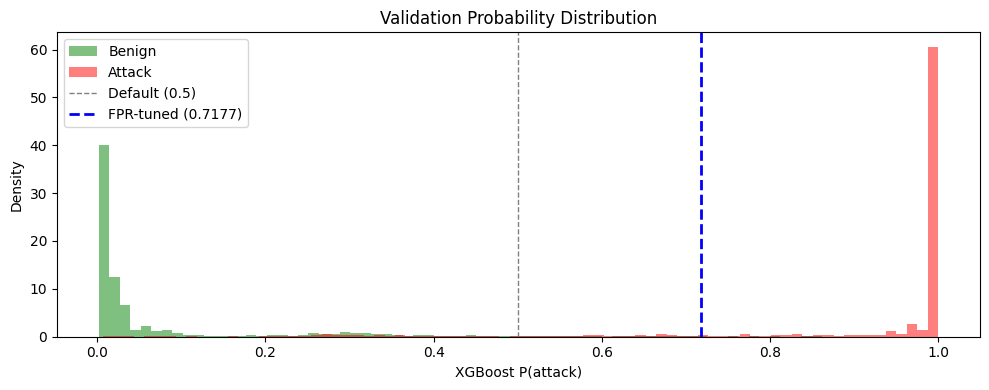

In [7]:
val_probs = model.predict_proba(X_val_scaled)[:, 1]  # P(attack)

# Threshold: find cutoff where FPR on benign val samples = TARGET_FPR
val_benign_probs = val_probs[y_val == 0]
# Attack if prob >= threshold; FPR = fraction of benign above threshold
# So threshold = (1 - TARGET_FPR) percentile of benign probs
fpr_threshold = np.percentile(val_benign_probs, (1 - TARGET_FPR) * 100)

val_preds_default = model.predict(X_val_scaled)
val_preds_tuned   = (val_probs >= fpr_threshold).astype(int)

val_benign_mask = y_val == 0
print(f"Threshold tuning on {sum(val_benign_mask):,} benign + {sum(y_val==1):,} attack validation samples:")
print(f"  Default predict() FPR: {val_preds_default[val_benign_mask].mean():.4f}")
print(f"  Tuned threshold:       {fpr_threshold:.4f}  (target FPR={TARGET_FPR})")
print(f"  Tuned FPR on val:      {val_preds_tuned[val_benign_mask].mean():.4f}")

fig, ax = plt.subplots(figsize=(10, 4))
ax.hist(val_benign_probs, bins=80, alpha=0.5, label="Benign", density=True, color="green")
ax.hist(val_probs[y_val == 1], bins=80, alpha=0.5, label="Attack", density=True, color="red")
ax.axvline(0.5, color="gray", ls="--", lw=1, label="Default (0.5)")
ax.axvline(fpr_threshold, color="blue", ls="--", lw=2, label=f"FPR-tuned ({fpr_threshold:.4f})")
ax.set_xlabel("XGBoost P(attack)")
ax.set_ylabel("Density")
ax.set_title("Validation Probability Distribution")
ax.legend()
plt.tight_layout()
plt.show()

## 7. Score Distribution on Test Set

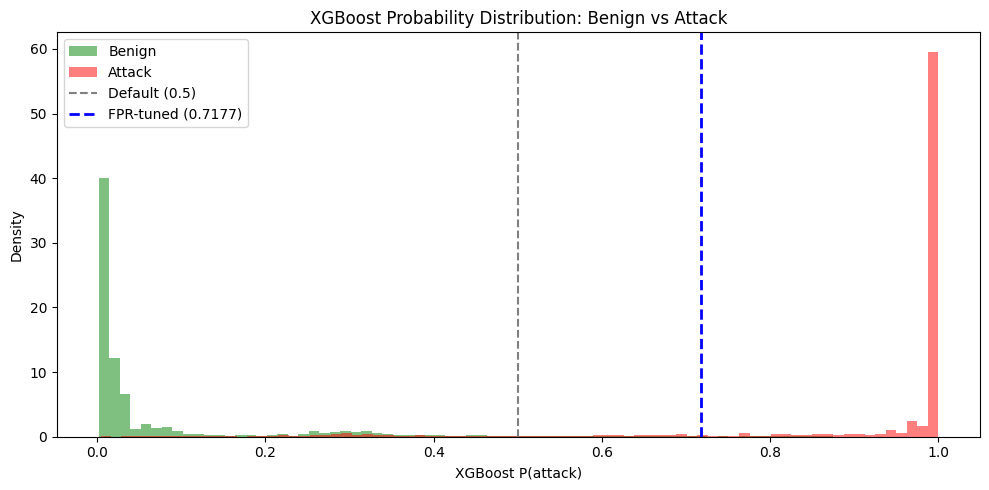

Benign probs — mean: 0.0789, std: 0.1517
Attack probs — mean: 0.9155, std: 0.2029


In [8]:
test_probs = model.predict_proba(X_test_scaled)[:, 1]

benign_mask = y_test == 0
attack_mask = y_test == 1

fig, ax = plt.subplots(figsize=(10, 5))
ax.hist(test_probs[benign_mask], bins=80, alpha=0.5, label="Benign", density=True, color="green")
ax.hist(test_probs[attack_mask], bins=80, alpha=0.5, label="Attack", density=True, color="red")
ax.axvline(0.5, color="gray", ls="--", lw=1.5, label="Default (0.5)")
ax.axvline(fpr_threshold, color="blue", ls="--", lw=2, label=f"FPR-tuned ({fpr_threshold:.4f})")
ax.set_xlabel("XGBoost P(attack)")
ax.set_ylabel("Density")
ax.set_title("XGBoost Probability Distribution: Benign vs Attack")
ax.legend()
plt.tight_layout()
plt.show()

print(f"Benign probs — mean: {test_probs[benign_mask].mean():.4f}, std: {test_probs[benign_mask].std():.4f}")
print(f"Attack probs — mean: {test_probs[attack_mask].mean():.4f}, std: {test_probs[attack_mask].std():.4f}")

## 8. Evaluation at Default Threshold (0.5)

=== Default threshold (0.5) ===

              precision    recall  f1-score   support

      Benign       0.97      0.97      0.97     36000
      Attack       0.91      0.92      0.91     12533

    accuracy                           0.96     48533
   macro avg       0.94      0.94      0.94     48533
weighted avg       0.96      0.96      0.96     48533



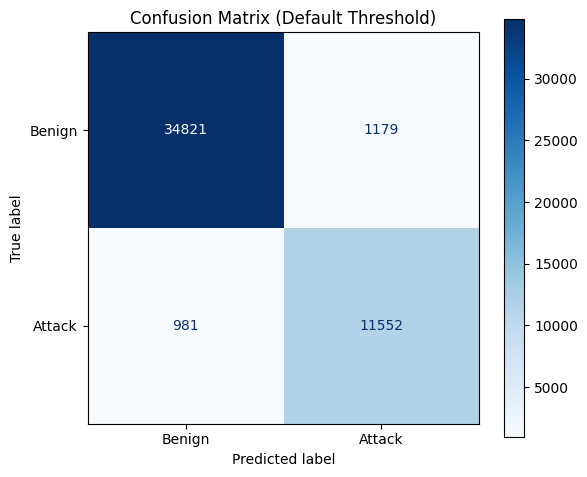

In [9]:
y_pred_default = model.predict(X_test_scaled)

print("=== Default threshold (0.5) ===\n")
print(classification_report(y_test, y_pred_default, target_names=["Benign", "Attack"]))

fig, ax = plt.subplots(figsize=(6, 5))
ConfusionMatrixDisplay.from_predictions(
    y_test, y_pred_default,
    display_labels=["Benign", "Attack"],
    cmap="Blues", ax=ax,
)
ax.set_title("Confusion Matrix (Default Threshold)")
plt.tight_layout()
plt.show()

## 9. Threshold Sweep — PR & ROC Curves

PR-AUC: 0.9782
Best F1: 0.9252 at threshold: 0.6961
  Precision: 0.9674
  Recall:    0.8866


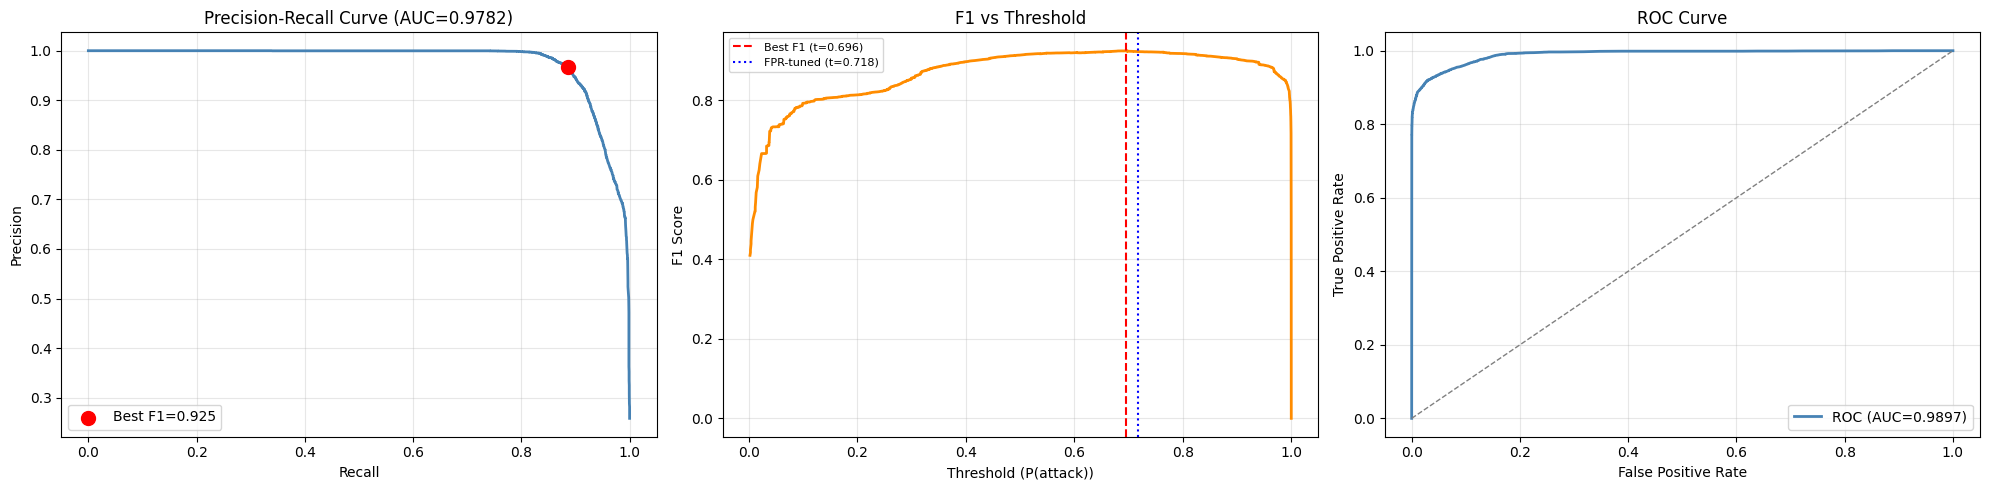

In [10]:
precisions, recalls, thresholds_pr = precision_recall_curve(y_test, test_probs)
pr_auc = average_precision_score(y_test, test_probs)

# F1 at each threshold
f1s = 2 * precisions[:-1] * recalls[:-1] / (precisions[:-1] + recalls[:-1] + 1e-10)
best_f1_idx = np.argmax(f1s)
f1_threshold = thresholds_pr[best_f1_idx]

print(f"PR-AUC: {pr_auc:.4f}")
print(f"Best F1: {f1s[best_f1_idx]:.4f} at threshold: {f1_threshold:.4f}")
print(f"  Precision: {precisions[best_f1_idx]:.4f}")
print(f"  Recall:    {recalls[best_f1_idx]:.4f}")

# ROC
roc_auc = roc_auc_score(y_test, test_probs)
fpr_arr, tpr_arr, _ = roc_curve(y_test, test_probs)

fig, axes = plt.subplots(1, 3, figsize=(20, 5))

# PR curve
axes[0].plot(recalls, precisions, lw=2, color="steelblue")
axes[0].scatter(recalls[best_f1_idx], precisions[best_f1_idx], color="red", s=100, zorder=5,
                label=f"Best F1={f1s[best_f1_idx]:.3f}")
axes[0].set_xlabel("Recall")
axes[0].set_ylabel("Precision")
axes[0].set_title(f"Precision-Recall Curve (AUC={pr_auc:.4f})")
axes[0].legend()
axes[0].grid(True, alpha=0.3)

# F1 vs threshold
axes[1].plot(thresholds_pr, f1s, lw=2, color="darkorange")
axes[1].axvline(f1_threshold, color="red", ls="--", label=f"Best F1 (t={f1_threshold:.3f})")
axes[1].axvline(fpr_threshold, color="blue", ls=":", label=f"FPR-tuned (t={fpr_threshold:.3f})")
axes[1].set_xlabel("Threshold (P(attack))")
axes[1].set_ylabel("F1 Score")
axes[1].set_title("F1 vs Threshold")
axes[1].legend(fontsize=8)
axes[1].grid(True, alpha=0.3)

# ROC curve
axes[2].plot(fpr_arr, tpr_arr, lw=2, color="steelblue", label=f"ROC (AUC={roc_auc:.4f})")
axes[2].plot([0, 1], [0, 1], ls="--", color="gray", lw=1)
axes[2].set_xlabel("False Positive Rate")
axes[2].set_ylabel("True Positive Rate")
axes[2].set_title("ROC Curve")
axes[2].legend()
axes[2].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

## 10. Evaluation at FPR-Tuned Threshold

=== FPR-tuned threshold (P(attack) >= 0.7177) ===

              precision    recall  f1-score   support

      Benign       0.96      0.99      0.97     36000
      Attack       0.97      0.88      0.92     12533

    accuracy                           0.96     48533
   macro avg       0.96      0.94      0.95     48533
weighted avg       0.96      0.96      0.96     48533



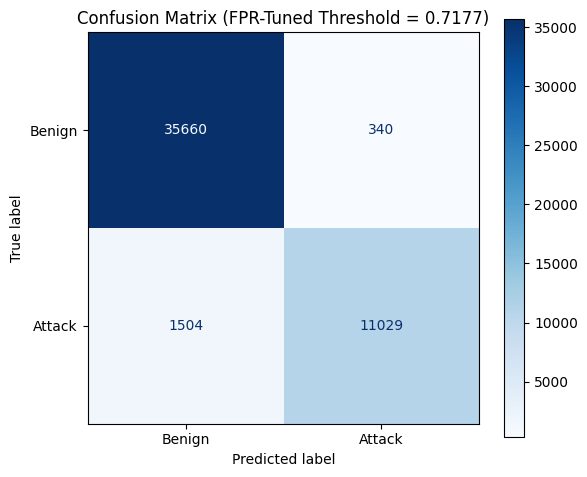

In [11]:
y_pred_tuned = (test_probs >= fpr_threshold).astype(int)

print(f"=== FPR-tuned threshold (P(attack) >= {fpr_threshold:.4f}) ===\n")
print(classification_report(y_test, y_pred_tuned, target_names=["Benign", "Attack"]))

fig, ax = plt.subplots(figsize=(6, 5))
ConfusionMatrixDisplay.from_predictions(
    y_test, y_pred_tuned,
    display_labels=["Benign", "Attack"],
    cmap="Blues", ax=ax,
)
ax.set_title(f"Confusion Matrix (FPR-Tuned Threshold = {fpr_threshold:.4f})")
plt.tight_layout()
plt.show()

## 11. Evaluation at F1-Optimal Threshold

=== F1-optimal threshold (P(attack) >= 0.6961) ===

              precision    recall  f1-score   support

      Benign       0.96      0.99      0.98     36000
      Attack       0.97      0.89      0.93     12533

    accuracy                           0.96     48533
   macro avg       0.96      0.94      0.95     48533
weighted avg       0.96      0.96      0.96     48533



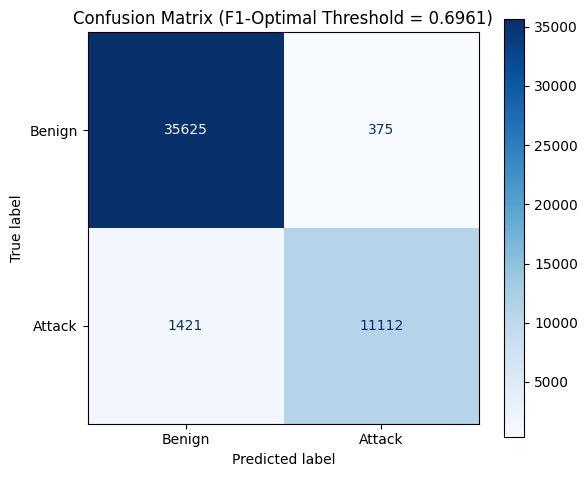

In [12]:
y_pred_f1 = (test_probs >= f1_threshold).astype(int)

print(f"=== F1-optimal threshold (P(attack) >= {f1_threshold:.4f}) ===\n")
print(classification_report(y_test, y_pred_f1, target_names=["Benign", "Attack"]))

fig, ax = plt.subplots(figsize=(6, 5))
ConfusionMatrixDisplay.from_predictions(
    y_test, y_pred_f1,
    display_labels=["Benign", "Attack"],
    cmap="Blues", ax=ax,
)
ax.set_title(f"Confusion Matrix (F1-Optimal Threshold = {f1_threshold:.4f})")
plt.tight_layout()
plt.show()

## 12. Feature Importance

XGBoost's built-in feature importance shows which features contribute most
to the supervised decision boundary — useful for understanding what
structural anomaly detectors (L2/L3) miss.

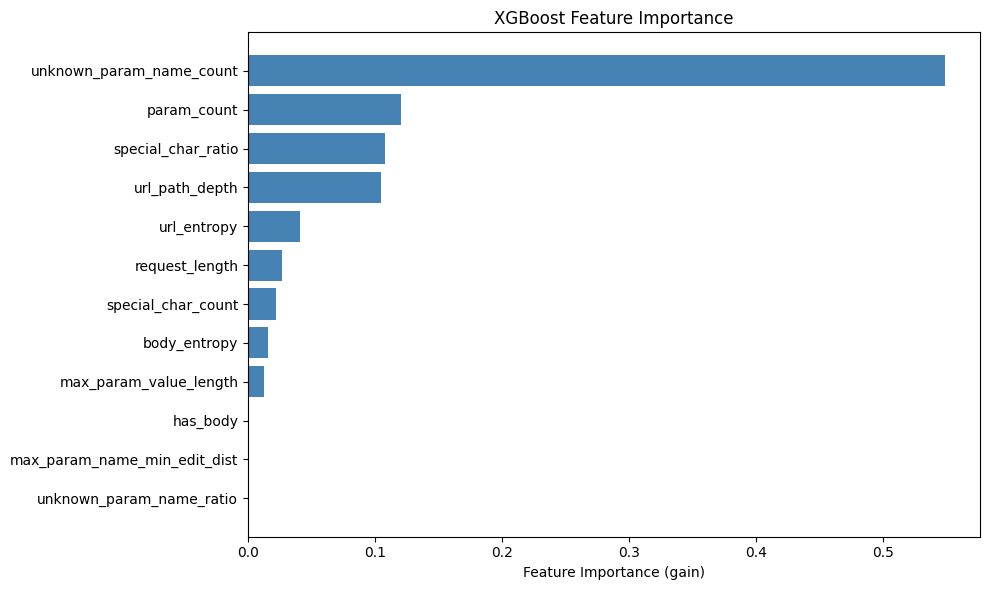

                     feature  importance
    unknown_param_name_count    0.548752
                 param_count    0.120143
          special_char_ratio    0.108021
              url_path_depth    0.104838
                 url_entropy    0.040945
              request_length    0.026728
          special_char_count    0.022262
                body_entropy    0.015854
      max_param_value_length    0.012456
                    has_body    0.000000
    unknown_param_name_ratio    0.000000
max_param_name_min_edit_dist    0.000000


In [13]:
importances = model.feature_importances_
feat_imp = pd.DataFrame({
    "feature": FEATURE_COLS,
    "importance": importances,
}).sort_values("importance", ascending=True)

fig, ax = plt.subplots(figsize=(10, 6))
ax.barh(feat_imp["feature"], feat_imp["importance"], color="steelblue")
ax.set_xlabel("Feature Importance (gain)")
ax.set_title("XGBoost Feature Importance")
plt.tight_layout()
plt.show()

print(feat_imp.sort_values("importance", ascending=False).to_string(index=False))

## 13. False Negative Analysis

True Positives  (attacks caught): 11,029
False Negatives (attacks missed): 1,504

FN feature statistics:
       request_length  special_char_count  special_char_ratio  url_entropy  \
count         1504.00             1504.00             1504.00      1504.00   
mean           715.37                1.98                0.01         4.56   
std            116.88                2.15                0.01         0.33   
min            503.00                0.00                0.00         4.07   
25%            581.00                0.00                0.00         4.29   
50%            754.00                1.00                0.00         4.32   
75%            830.00                4.00                0.01         4.81   
max            892.00                8.00                0.03         5.27   

       body_entropy  param_count  max_param_value_length  url_path_depth  \
count       1504.00      1504.00                 1504.00         1504.00   
mean           2.37         9.29        

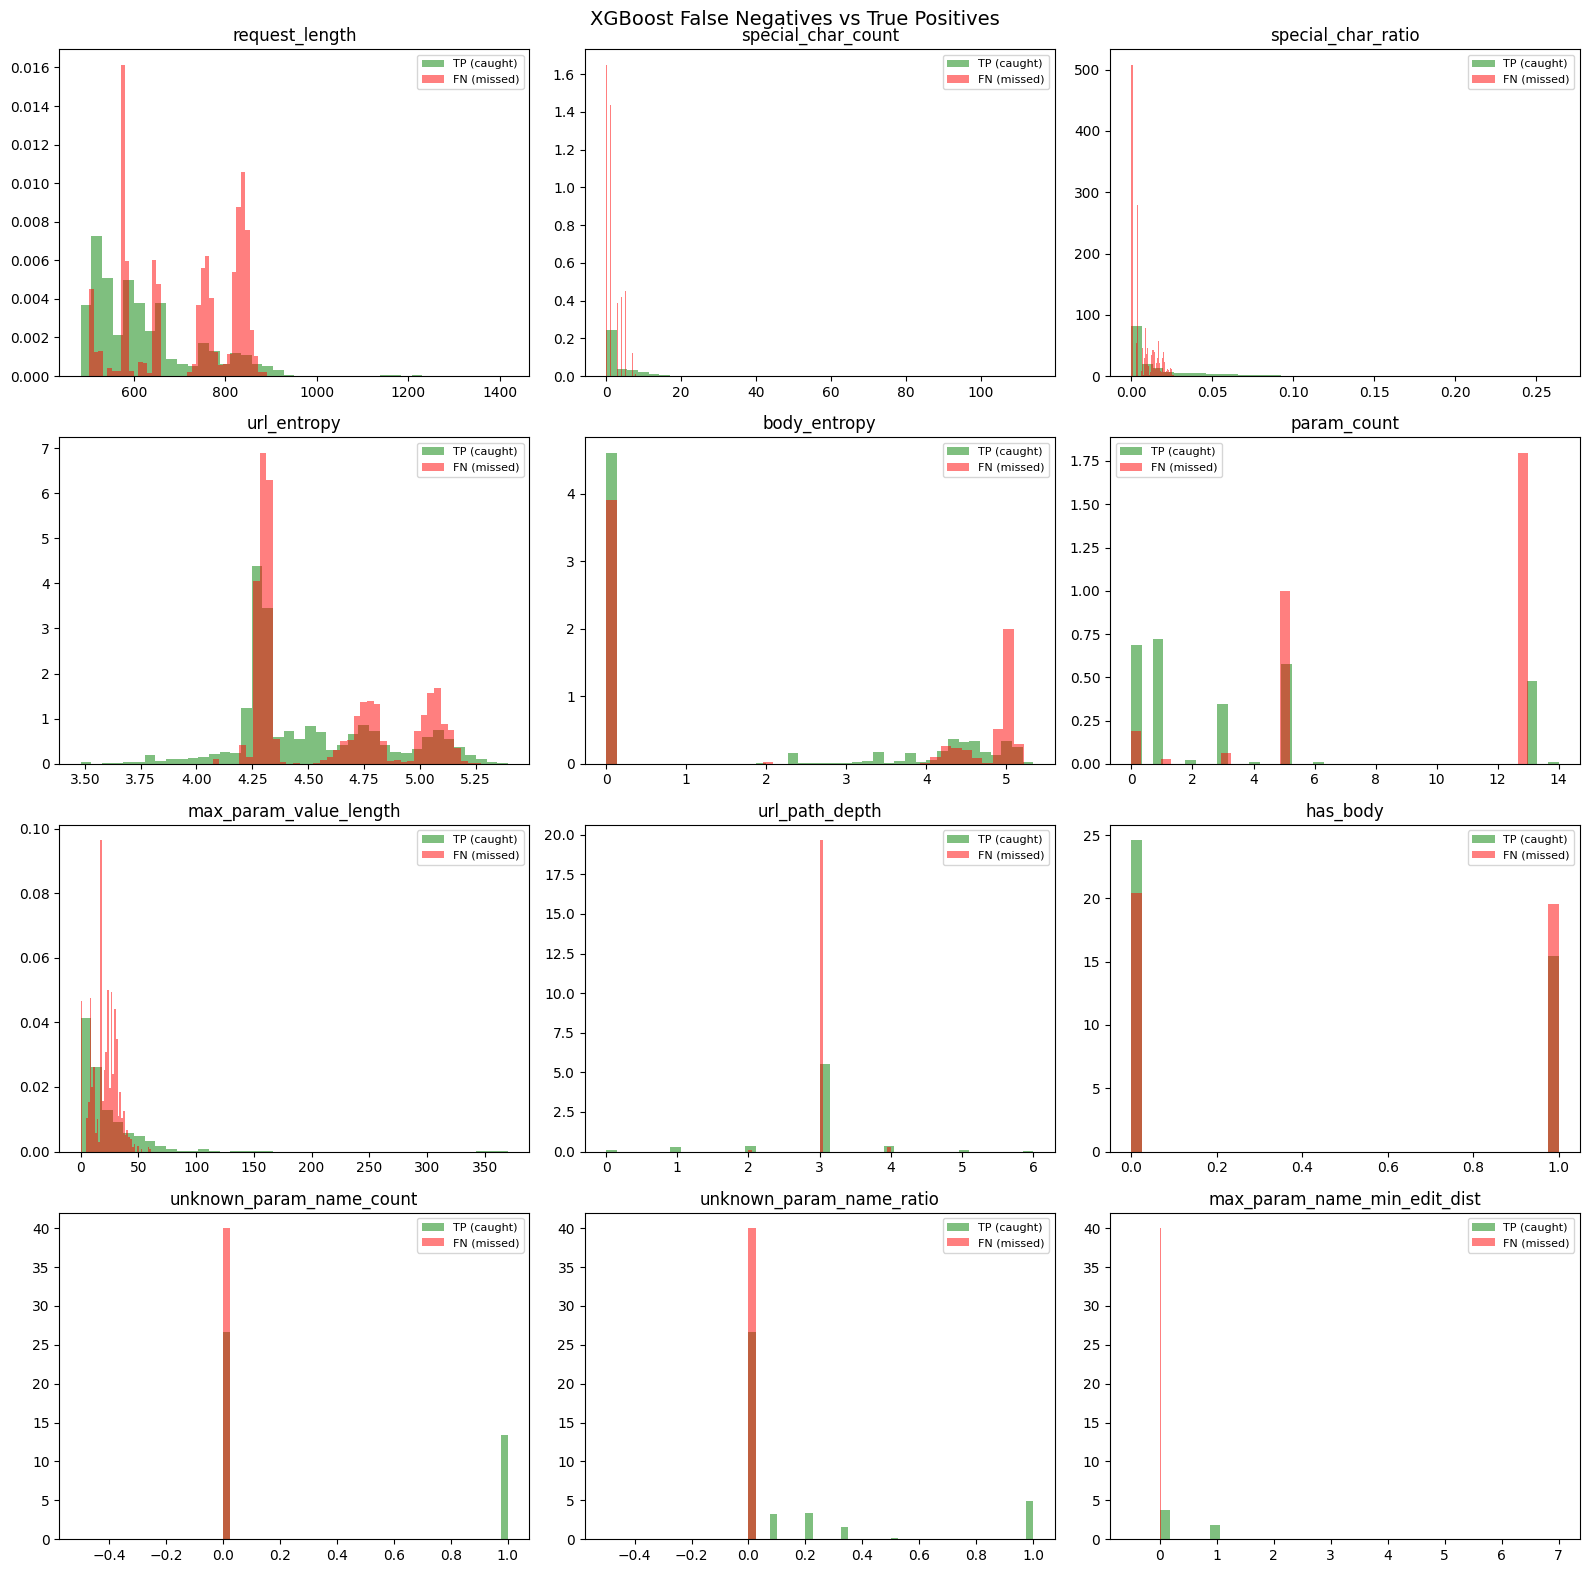

In [14]:
y_eval = y_pred_tuned  # FPR-tuned threshold

fn_mask = (y_test == 1) & (y_eval == 0)
tp_mask = (y_test == 1) & (y_eval == 1)

fn_features = X_test.loc[fn_mask, FEATURE_COLS]
tp_features = X_test.loc[tp_mask, FEATURE_COLS]

print(f"True Positives  (attacks caught): {tp_mask.sum():,}")
print(f"False Negatives (attacks missed): {fn_mask.sum():,}")
print(f"\nFN feature statistics:\n{fn_features.describe().round(2)}")
print(f"\nTP feature statistics:\n{tp_features.describe().round(2)}")

n_feats = len(FEATURE_COLS)
ncols = 3
nrows = math.ceil(n_feats / ncols)
fig, axes = plt.subplots(nrows, ncols, figsize=(16, 4 * nrows))
for ax in axes.flat[n_feats:]:
    ax.set_visible(False)
for ax, col in zip(axes.flat, FEATURE_COLS):
    ax.hist(tp_features[col], bins=40, alpha=0.5, label="TP (caught)", density=True, color="green")
    if len(fn_features) > 0:
        ax.hist(fn_features[col], bins=40, alpha=0.5, label="FN (missed)", density=True, color="red")
    ax.set_title(col)
    ax.legend(fontsize=8)
fig.suptitle("XGBoost False Negatives vs True Positives", fontsize=14)
plt.tight_layout()
plt.show()

### 13.1 Sample False Negatives

In [15]:
fn_df = df_xgb_test.loc[fn_mask].copy()
fn_df = fn_df.assign(**X_test.loc[fn_mask, FEATURE_COLS].to_dict())
fn_df["xgb_prob"] = test_probs[fn_mask]

sample_cols = ["method", "url"] + FEATURE_COLS + ["xgb_prob"]
display_cols = [c for c in sample_cols if c in fn_df.columns]
print(f"Sample false negatives (attacks missed by XGBoost):\n")
print(fn_df[display_cols].head(10).to_string(max_colwidth=80))

Sample false negatives (attacks missed by XGBoost):

      method                                                                              url  request_length  special_char_count  special_char_ratio  url_entropy  body_entropy  param_count  max_param_value_length  url_path_depth  has_body  unknown_param_name_count  unknown_param_name_ratio  max_param_name_min_edit_dist  xgb_prob
36001   POST                                http://localhost:8080/tienda1/miembros/editar.jsp             830                   5            0.016835     4.288307      5.046776           13                      23               3         1                         0                       0.0                             0  0.590448
36003   POST                                http://localhost:8080/tienda1/miembros/editar.jsp             839                   6            0.019608     4.288307      5.061001           13                      23               3         1                         0                  

## 14. False Positive Analysis

In [16]:
fp_mask = (y_test == 0) & (y_eval == 1)
tn_mask = (y_test == 0) & (y_eval == 0)

print(f"True Negatives  (benign correctly passed): {tn_mask.sum():,}")
print(f"False Positives (benign flagged as attack): {fp_mask.sum():,}")
print(f"False Positive Rate: {fp_mask.sum() / (fp_mask.sum() + tn_mask.sum()):.4f}")

if fp_mask.sum() > 0:
    fp_features = X_test.loc[fp_mask, FEATURE_COLS]
    print(f"\nFP feature statistics:\n{fp_features.describe().round(2)}")

    fp_df = df_xgb_test.loc[fp_mask].copy()
    fp_df = fp_df.assign(**X_test.loc[fp_mask, FEATURE_COLS].to_dict())
    fp_df["xgb_prob"] = test_probs[fp_mask]
    sample_cols = ["method", "url"] + FEATURE_COLS + ["xgb_prob"]
    display_cols = [c for c in sample_cols if c in fp_df.columns]
    print(f"\nSample false positives:\n")
    print(fp_df[display_cols].head(10).to_string(max_colwidth=80))
else:
    print("No false positives at this threshold.")

True Negatives  (benign correctly passed): 35,660
False Positives (benign flagged as attack): 340
False Positive Rate: 0.0094

FP feature statistics:
       request_length  special_char_count  special_char_ratio  url_entropy  \
count          340.00              340.00              340.00       340.00   
mean           730.67                2.76                0.01         4.73   
std             93.86                2.19                0.01         0.37   
min            545.00                0.00                0.00         4.26   
25%            647.00                1.00                0.01         4.29   
50%            757.00                2.00                0.01         4.81   
75%            777.25                3.00                0.02         5.08   
max            895.00                9.00                0.03         5.27   

       body_entropy  param_count  max_param_value_length  url_path_depth  \
count        340.00       340.00                  340.00           340.

## 15. Summary

In [17]:
p_def = precision_score(y_test, y_pred_default)
r_def = recall_score(y_test, y_pred_default)
f1_def = f1_score(y_test, y_pred_default)

p_tuned = precision_score(y_test, y_pred_tuned)
r_tuned = recall_score(y_test, y_pred_tuned)
f1_tuned = f1_score(y_test, y_pred_tuned)

p_f1 = precision_score(y_test, y_pred_f1)
r_f1 = recall_score(y_test, y_pred_f1)
f1_f1 = f1_score(y_test, y_pred_f1)

summary = pd.DataFrame({
    "Metric":     ["Precision", "Recall", "F1-Score", "PR-AUC", "ROC-AUC", "Threshold"],
    "Default":    [f"{p_def:.4f}", f"{r_def:.4f}", f"{f1_def:.4f}", "", "", "0.5000"],
    "FPR-tuned":  [f"{p_tuned:.4f}", f"{r_tuned:.4f}", f"{f1_tuned:.4f}",
                   f"{pr_auc:.4f}", f"{roc_auc:.4f}", f"{fpr_threshold:.4f}"],
    "F1-optimal": [f"{p_f1:.4f}", f"{r_f1:.4f}", f"{f1_f1:.4f}",
                   "", "", f"{f1_threshold:.4f}"],
})
print(summary.to_string(index=False))
print(f"\nRecommendation: Use the FPR-tuned threshold ({fpr_threshold:.4f}) for")
print(f"cascade deployment to maintain controlled false alarm rate.")
print(f"The F1-optimal threshold ({f1_threshold:.4f}) is reported for thesis completeness.")

   Metric Default FPR-tuned F1-optimal
Precision  0.9074    0.9701     0.9674
   Recall  0.9217    0.8800     0.8866
 F1-Score  0.9145    0.9229     0.9252
   PR-AUC            0.9782           
  ROC-AUC            0.9897           
Threshold  0.5000    0.7177     0.6961

Recommendation: Use the FPR-tuned threshold (0.7177) for
cascade deployment to maintain controlled false alarm rate.
The F1-optimal threshold (0.6961) is reported for thesis completeness.


## 16. Persist Scaler + Model

Same artifact pattern as L2 — single dict bundling scaler, model, threshold,
feature columns, and the fitted `ParamVocab`. Independent scaler prevents
cross-layer contamination; bundling the vocab guarantees inference-time
feature parity (same known-name set used at training).

In [18]:
artifact = {
    "scaler": xgb_scaler,
    "model": model,
    "threshold": fpr_threshold,
    "threshold_f1_optimal": f1_threshold,
    "vocab": vocab,
    "feature_cols": FEATURE_COLS,
    "hyperparams": {
        "n_estimators": N_ESTIMATORS,
        "max_depth": MAX_DEPTH,
        "learning_rate": LEARNING_RATE,
        "scale_pos_weight": spw,
        "val_size": VAL_SIZE,
        "attack_split": ATTACK_SPLIT,
        "target_fpr": TARGET_FPR,
    },
}

save_path = os.path.join(MODEL_DIR, "web_attack_xgboost.pkl")
joblib.dump(artifact, save_path)

# Verify round-trip
loaded = joblib.load(save_path)
assert list(loaded["feature_cols"]) == FEATURE_COLS
assert loaded["vocab"].known_names == vocab.known_names
print(f"Saved to {save_path}")
print(f"  FPR-tuned threshold:  {loaded['threshold']:.4f}")
print(f"  F1-optimal threshold: {loaded['threshold_f1_optimal']:.4f}")
print(f"  Features:    {loaded['feature_cols']}")
print(f"  Vocab size:  {len(loaded['vocab'].known_names)} known param names")
print(f"  Scaler:      {type(loaded['scaler']).__name__}")
print(f"  Model:       {type(loaded['model']).__name__}")
print(f"  Hyperparams: {loaded['hyperparams']}")


Saved to ./models\web_attack_xgboost.pkl
  FPR-tuned threshold:  0.7177
  F1-optimal threshold: 0.6961
  Features:    ['request_length', 'special_char_count', 'special_char_ratio', 'url_entropy', 'body_entropy', 'param_count', 'max_param_value_length', 'url_path_depth', 'has_body', 'unknown_param_name_count', 'unknown_param_name_ratio', 'max_param_name_min_edit_dist']
  Vocab size:  20 known param names
  Scaler:      StandardScaler
  Model:       XGBClassifier
  Hyperparams: {'n_estimators': 200, 'max_depth': 6, 'learning_rate': 0.1, 'scale_pos_weight': np.float64(2.8728179551122195), 'val_size': 0.2, 'attack_split': 0.5, 'target_fpr': 0.01}
